## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../Modules")
sys.path.insert(0, "../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001DBCBBA0D40> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'

In [4]:
timeline_file = pd.read_csv(f'../data/{NUTS0}_Timeline_GRID_2009-2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)


In [5]:
timeline_file.head()

,Unnamed: 0,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,0,19.656538,39.718959,HL24,2009-01-01,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.707780,1,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,6.707780,6.707780,6.707780,6.707780
1,1,19.656538,39.718959,HL24,2009-01-02,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.564106,2,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,16.271885,16.271885,16.271885,16.271885
2,2,19.656538,39.718959,HL24,2009-01-03,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.859431,3,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,91.131317,91.131317,91.131317,91.131317
3,3,19.656538,39.718959,HL24,2009-01-04,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.159674,4,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,105.290990,105.290990,105.290990,105.290990
4,4,19.656538,39.718959,HL24,2009-01-05,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,105.290990,105.290990,105.290990,105.290990


In [6]:
timeline_file.shape

(22522765, 44)

In [7]:
wnv_file.head()

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0


In [8]:
wnv_file.shape

(52876, 3)

In [9]:
timeline_file.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [11]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [12]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [13]:
timeline_file

,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,19.656538,39.718959,HL24,2009-01-01,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.707780,1,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,6.707780,6.707780,6.707780,6.707780,NaN,14038.918750,14104.946429,14182.064516,14384.900000,0.500000,0.866025
1,19.656538,39.718959,HL24,2009-01-02,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.564106,2,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,16.271885,16.271885,16.271885,16.271885,NaN,14038.918750,14104.946429,14182.064516,14384.900000,0.500000,0.866025
2,19.656538,39.718959,HL24,2009-01-03,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.859431,3,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,91.131317,91.131317,91.131317,91.131317,NaN,14038.918750,14104.946429,14182.064516,14384.900000,0.500000,0.866025
3,19.656538,39.718959,HL24,2009-01-04,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.159674,4,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,105.290990,105.290990,105.290990,105.290990,NaN,14038.918750,14104.946429,14182.064516,14384.900000,0.500000,0.866025
4,19.656538,39.718959,HL24,2009-01-05,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,105.290990,105.290990,105.290990,105.290990,NaN,14038.918750,14104.946429,14182.064516,14384.900000,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22522760,27.860317,36.529297,VD742,2022-12-27,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000
22522761,27.860317,36.529297,VD742,2022-12-28,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000
22522762,27.860317,36.529297,VD742,2022-12-29,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000
22522763,27.860317,36.529297,VD742,2022-12-30,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000

In [14]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [15]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_code','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [24]:
grouped_by_month_mean

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14326.791667,14045.709677,11.289533,16.000000,14326.791667,14045.709677,14256.750000,14178.642857,14451.903226,14007.677419,14754.466667,14201.666667,69.675667,124.789480,198.837012,198.922431,14198.062500,14186.250672,14217.696429,14229.790323,14478.066667,0.500000,0.866025
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14256.750000,14178.642857,14.562216,14.500000,14326.791667,14045.709677,14256.750000,14178.642857,14451.903226,14007.677419,14754.466667,14201.666667,101.711578,188.662202,342.750185,538.278193,14217.696429,14186.250672,14217.696429,14229.790323,14478.066667,0.866025,0.500000
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,14451.903226,14007.677419,6.033606,16.000000,14326.791667,14045.709677,14256.750000,14178.642857,14451.903226,14007.677419,14754.466667,14201.666667,50.412024,123.981315,351.138909,884.408596,14229.790323,14186.250672,14217.696429,14229.790323,14478.066667,1.000000,0.000000
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,14754.466667,14201.666667,4.573572,15.500000,14326.791667,14045.709677,14256.750000,14178.642857,14451.903226,14007.677419,14754.466667,14201.666667,32.448004,66.873231,162.180222,1050.388847,14478.066667,14186.250672,14217.696429,14229.790323,14478.066667,0.866025,-0.500000
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,15032.516129,14405.677419,2.087833,16.000000,14326.791667,14045.709677,14256.750000,14178.642857,14451.903226,14007.677419,14754.466667,14201.666667,15.471587,32.834753,76.663468,1128.070950,14719.096774,14186.250672,14217.696429,14229.790323,14478.066667,0.500000,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,8.000000,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,15297.064516,14780.354839,0.974678,16.000000,14290.225806,14045.032258,14395.035714,14020.714286,14451.000000,13950.354839,14667.266667,14266.700000,1.601303,1.696395,1.696395,1034.896717,15038.709677,14167.629032,14207.875000,14200.677419,14466.983333,-0.866025,-0.500000
715676,ZV382,2022-09,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,9.000000,0.439553,0.128380,-0.418841,-0.128380,0.452942,0.159895,-0.419358

In [25]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_code','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [29]:
grouped_by_month_dataset.head()

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14326.791667,14045.709677,14198.062500,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,11.289533,89.988620,121.504665,347.327549,349.975530,14176.000000,13909.000000,14423.000000,14348.000000,349.975530
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14256.750000,14178.642857,14217.696429,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,14.562216,133.844776,205.302734,422.839291,757.717577,14025.000000,13838.000000,14577.000000,14211.000000,407.742047
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,14451.903226,14007.677419,14229.790323,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,6.033606,16.994903,36.774120,174.351656,944.759366,14050.000000,13838.000000,14612.000000,14193.000000,187.041788
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,14754.466667,14201.666667,14478.066667,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,4.573572,12.160266,19.701893,137.207154,1081.966519,14501.000000,14065.000000,14952.000000,14383.000000,137.207154
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,15032.516129,14405.677419,14719.096774,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,2.087833,1.402261,21.129889,64.722820,1146.689339,14681.000000,14162.000000,15405.000000,14651.000000,64.722820


In [32]:
grouped_by_month_dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14326.791667,14045.709677,14198.062500,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,11.289533,89.988620,121.504665,347.327549,349.975530,14176.000000,13909.000000,14423.000000,14348.000000,349.975530
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14256.750000,14178.642857,14217.696429,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,14.562216,133.844776,205.302734,422.839291,757.717577,14025.000000,13838.000000,14577.000000,14211.000000,407.742047
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,14451.903226,14007.677419,14229.790323,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,6.033606,16.994903,36.774120,174.351656,944.759366,14050.000000,13838.000000,14612.000000,14193.000000,187.041788
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,14754.466667,14201.666667,14478.066667,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,4.573572,12.160266,19.701893,137.207154,1081.966519,14501.000000,14065.000000,14952.000000,14383.000000,137.207154
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,15032.516129,14405.677419,14719.096774,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,2.087833,1.402261,21.129889,64.722820,1146.689339,14681.000000,14162.000000,15405.000000,14651.000000,64.722820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,8.000000,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,15297.064516,14780.354839,15038.709677,14290.225806,14395.035714,14451.000000,14667.266667,14045.032258,14020.714286,13950.354839,14266.700000,14167.629032,14207.875000,14200.677419,14466.983333,0.974678,27.689264,30.215026,30.215026,1063.41

In [33]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [34]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [35]:
grouped_by_month_dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14326.791667,14045.709677,14198.062500,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,13909.000000,14423.000000
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14256.750000,14178.642857,14217.696429,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,13838.000000,14577.000000
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,14451.903226,14007.677419,14229.790323,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,13838.000000,14612.000000
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,14754.466667,14201.666667,14478.066667,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,4.573572,12.160266,19.701893,137.207154,1081.966519,137.207154,14065.000000,14952.000000
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,15032.516129,14405.677419,14719.096774,14326.791667,14256.750000,14451.903226,14754.466667,14045.709677,14178.642857,14007.677419,14201.666667,14186.250672,14217.696429,14229.790323,14478.066667,2.087833,1.402261,21.129889,64.722820,1146.689339,64.722820,14162.000000,15405.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,8.000000,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,15297.064516,14780.354839,15038.709677,14290.225806,14395.035714,14451.000000,14667.266667,14045.032258,14020.714286,13950.354839,14266.700000,14167.629032,14207.875000,14200.677419,14466.983333,0.974678,27.689264,30.215026,30.215026,1063.415348,30.215026,14654.000000,15569.000000
715676,ZV382,2022-09,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,

In [37]:
temprature_cols = grouped_by_month_dataset.filter(regex='^lst_*').columns.tolist()

grouped_by_month_dataset[temprature_cols] = grouped_by_month_dataset[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [39]:
temprature_cols

['lst_day_mean',
 'lst_night_mean',
 'lst_mean',
 'lst_jan_day_mean',
 'lst_feb_day_mean',
 'lst_mar_day_mean',
 'lst_apr_day_mean',
 'lst_jan_night_mean',
 'lst_feb_night_mean',
 'lst_mar_night_mean',
 'lst_apr_night_mean',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'lst_min',
 'lst_max']

In [38]:
grouped_by_month_dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-272.882283,-272.994716,-272.933775,-272.882283,-272.910300,-272.832239,-272.711213,-272.994716,-272.941543,-273.009929,-272.932333,-272.938500,-272.925921,-272.921084,-272.821773,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,-273.049400,-272.843800
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-272.910300,-272.941543,-272.925921,-272.882283,-272.910300,-272.832239,-272.711213,-272.994716,-272.941543,-273.009929,-272.932333,-272.938500,-272.925921,-272.921084,-272.821773,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,-273.077800,-272.782200
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,-272.832239,-273.009929,-272.921084,-272.882283,-272.910300,-272.832239,-272.711213,-272.994716,-272.941543,-273.009929,-272.932333,-272.938500,-272.925921,-272.921084,-272.821773,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,-273.077800,-272.768200
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,-272.711213,-272.932333,-272.821773,-272.882283,-272.910300,-272.832239,-272.711213,-272.994716,-272.941543,-273.009929,-272.932333,-272.938500,-272.925921,-272.921084,-272.821773,4.573572,12.160266,19.701893,137.207154,1081.966519,137.207154,-272.987000,-272.632200
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,-272.599994,-272.850729,-272.725361,-272.882283,-272.910300,-272.832239,-272.711213,-272.994716,-272.941543,-273.009929,-272.932333,-272.938500,-272.925921,-272.921084,-272.821773,2.087833,1.402261,21.129889,64.722820,1146.689339,64.722820,-272.948200,-272.451000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,8.000000,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,-272.494174,-272.700858,-272.597516,-272.896910,-272.854986,-272.832600,-272.746093,-272.994987,-273.004714,-273.032858,-272.906320,-272.945948,-272.929850,-272.932729,-272.826207,0.974678,27.689264,30.215026,30.215026,1063.415348,30.215026,-272.751400,-272.385400
715676,ZV382,2022-09,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,9.000000,0.439553,0.128380,-0.418841,-0.128380,0.452942,0.159895,-0.419358,-0.159895,0.049214,0.050873

In [53]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [54]:
bio_values_df = pd.DataFrame(bio_values)

In [55]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,ημαθια,2009,1,-11.190000,12.110000,222.648418
1,ημαθια,2009,2,-4.552963,13.439630,58.031937
2,ημαθια,2009,3,-0.725185,17.720741,77.556888
3,ημαθια,2009,4,3.366604,25.194074,72.607600
4,ημαθια,2009,5,6.810741,33.854815,99.328856
...,...,...,...,...,...,...
1255,χαλκιδικη,2023,8,19.645402,36.664253,1.182073
1256,χαλκιδικη,2023,9,15.600115,32.567701,123.863567
1257,χαλκιδικη,2023,10,12.152529,27.675977,21.629721
1258,χαλκιδικη,2023,11,0.725172,23.450690,251.475013


In [56]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [57]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.331923,1.331923,NaN,NaN,NaN,-11.190000,-11.190000,NaN,NaN,NaN,-4.929038,-5.730000,NaN,NaN,NaN,9.577106,9.577106,9.577106,9.577106,9.577106,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.226290,4.226290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.750929,1.750929,1.750929,1.750929,1.750929,34.773438,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.049121,4.049121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.920203,1.920203,1.920203,1.920203,1.920203,32.619565,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.520986,2.520986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.509716,6.509716,6.509716,6.509716,6.509716,38.568182,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.474390,2.474390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.911587,12.91158

<AxesSubplot:>

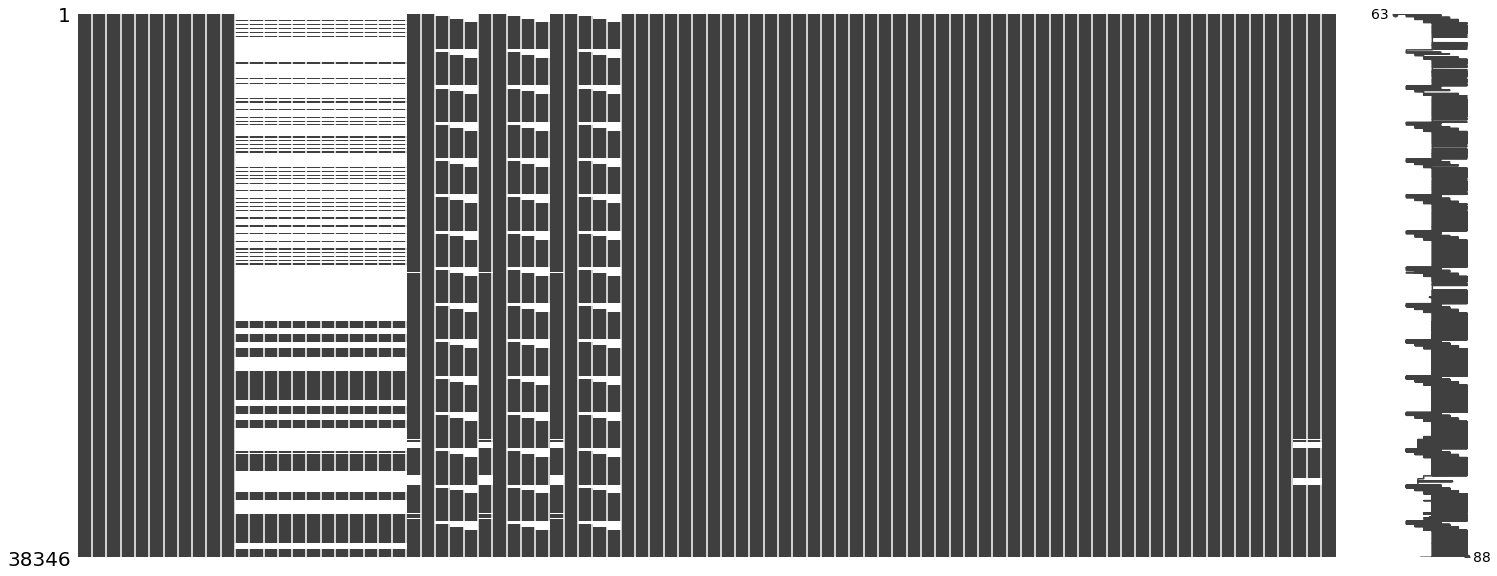

In [58]:
missingno.matrix(dataset)

In [59]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [61]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.331923,1.331923,NaN,NaN,NaN,-11.190000,-11.190000,NaN,NaN,NaN,-4.929038,-5.730000,NaN,NaN,NaN,9.577106,9.577106,9.577106,9.577106,9.577106,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,2009-01
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.226290,4.226290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.750929,1.750929,1.750929,1.750929,1.750929,34.773438,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,2009-01
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.049121,4.049121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.920203,1.920203,1.920203,1.920203,1.920203,32.619565,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679,2009-01
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.520986,2.520986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.509716,6.509716,6.509716,6.509716,6.509716,38.568182,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134,2009-01
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.474390,2.474390,NaN,NaN,NaN,NaN,NaN

In [71]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.263846,1.331923,NaN,NaN,NaN,-1.414151,-8.470000,NaN,NaN,NaN,-3.130256,-3.280000,NaN,NaN,NaN,0.000000,9.577106,45.918565,45.918565,45.918565,6.962963,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418
1,1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,2,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,2.388548,4.226290,NaN,NaN,NaN,1.931250,-2.562267,NaN,NaN,NaN,-1.225079,1.036667,NaN,NaN,NaN,0.000000,1.750929,19.391556,19.391556,19.391556,1.320312,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214
2,2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,2,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,2.930659,3.241403,NaN,NaN,NaN,-2.247174,-3.931569,NaN,NaN,NaN,-3.030385,-1.757031,NaN,NaN,NaN,0.000000,1.920203,39.703037,39.703037,39.703037,1.532609,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679
3,3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,2,0.107654,0.289068,0.166464,-0.478786,0.132639,0.294365,0.186765,-0.484606,0.036793,0.056441,0.078150,0.056441,0.221795,0.734225,NaN,NaN,NaN,-6.367647,-7.760000,NaN,NaN,NaN,-3.072926,-5.108636,NaN,NaN,NaN,0.000000,6.509716,77.994794,77.994794,77.994794,8.113636,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,

In [78]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [79]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679
3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2009,0.128263,0.383927,0.293472,-0.383927,0.138674,0.389485,0.298207,-0.389485,0.039301,0.057925,0.081700,0.057925,5.700504,-1.788882,2.135979,5.898683,NaN,NaN,NaN,-0.518737,NaN,NaN,NaN,2.689973,NaN,NaN,NaN,7.656553,32.328814,136.515678,230.843418,237.353134,565.079545,18.228372,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.20039

In [80]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [81]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1260 non-null   period[M]
 1   NUTS2_ID                1260 non-null   object   
 2   NUTS2_NAME              1260 non-null   object   
 3   NUTS3_ID                1260 non-null   object   
 4   NUTS3_NAME              1260 non-null   object   
 5   x                       1260 non-null   float64  
 6   y                       1260 non-null   float64  
 7   month                   1260 non-null   int64    
 8   year                    1260 non-null   int64    
 9   ndvi                    1184 non-null   float64  
 10  ndmi                    1184 non-null   float64  
 11  ndwi                    1184 non-null   float64  
 12  ndbi                    1184 non-null   float64  
 13  ndvi_mean               1185 non-null   float64  
 14  ndmi_mea

In [82]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    420 non-null    object
 1   NUTS3_NAME    420 non-null    object
 2   dt_placement  420 non-null    object
 3   cases         420 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 13.2+ KB


In [83]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [84]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0
...,...,...,...,...
415,κεντρικη μακεδονια,χαλκιδικη,2023-07,0
416,κεντρικη μακεδονια,χαλκιδικη,2023-08,0
417,κεντρικη μακεδονια,χαλκιδικη,2023-09,6
418,κεντρικη μακεδονια,χαλκιδικη,2023-10,0


In [85]:
wnv_file['cases'].value_counts()

0     265
1      42
2      26
3      18
4      13
5       8
6       7
7       6
11      6
10      5
12      4
13      3
8       3
9       2
17      2
20      2
16      1
41      1
27      1
49      1
40      1
50      1
36      1
34      1
Name: cases, dtype: int64

In [86]:
wnv_file.cases.sum()

936

In [87]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [88]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679,NaN
3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2009,0.128263,0.383927,0.293472,-0.383927,0.138674,0.389485,0.298207,-0.389485,0.039301,0.057925,0.081700,0.057925,5.700504,-1.788882,2.135979,5.898683,NaN,NaN,NaN,-0.518737,NaN,NaN,NaN,2.689973,NaN,NaN,NaN,7.656553,32.328814,136.515678,230.843418,237.353134,565.079545,18.228372,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,

In [89]:
merged = fillna(merged,{'cases': 0})

In [90]:
merged['cases'].value_counts()

0.000000     1105
1.000000       42
2.000000       26
3.000000       18
4.000000       13
5.000000        8
6.000000        7
11.000000       6
7.000000        6
10.000000       5
12.000000       4
8.000000        3
13.000000       3
9.000000        2
20.000000       2
17.000000       2
41.000000       1
50.000000       1
16.000000       1
34.000000       1
27.000000       1
40.000000       1
49.000000       1
36.000000       1
Name: cases, dtype: int64

In [91]:
merged.cases.sum()

936.0

In [92]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

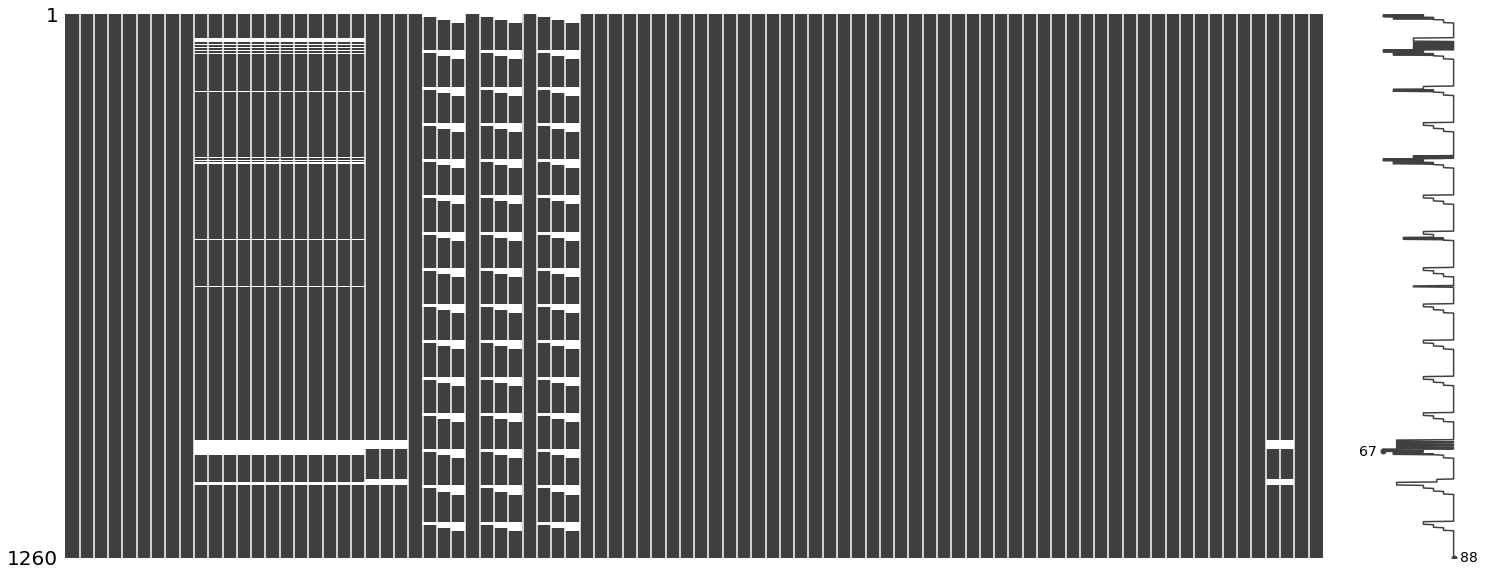

In [93]:
missingno.matrix(merged)

In [94]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

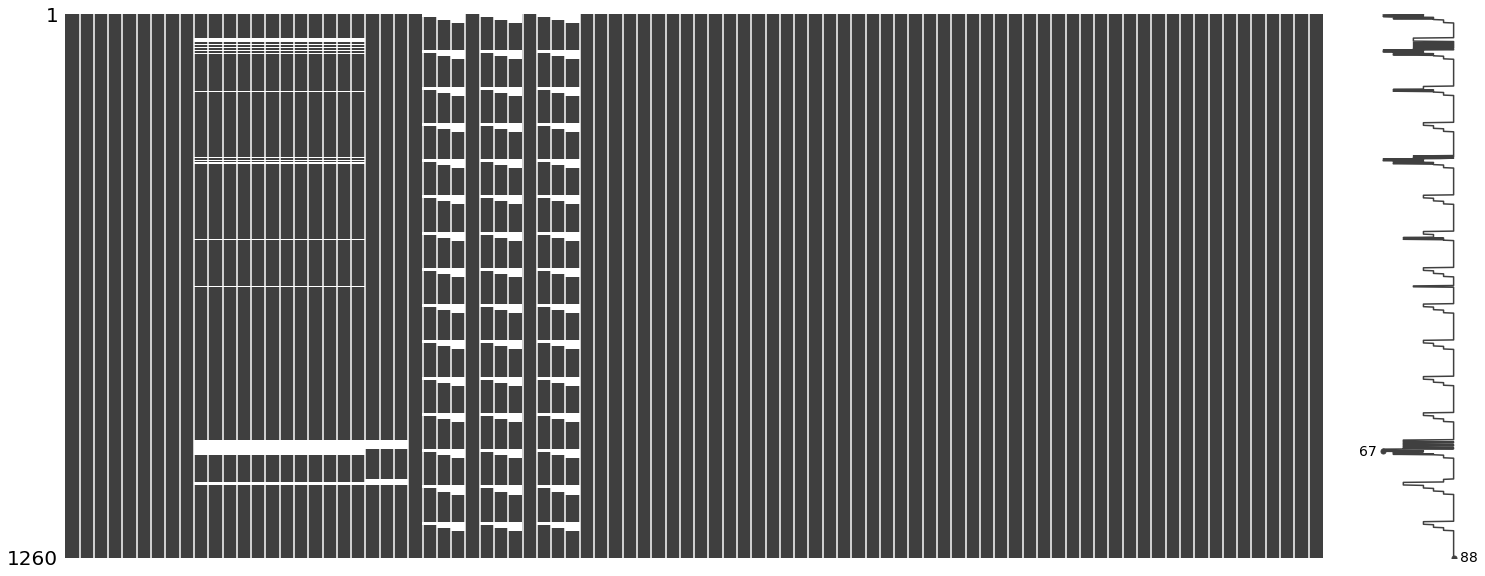

In [95]:
missingno.matrix(merged)

In [96]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023], dtype=int64)

In [97]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['ημαθια', 'θεσσαλονικη', 'κιλκις', 'πελλα', 'πιερια', 'σερρες',
       'χαλκιδικη'], dtype=object)

In [98]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [99]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,ημαθια,2009,14.333333,19.666667,40.972222,832.120329,37.000000,-11.000000,48.000000,5.500000,23.500000,24.000000,4.166667,1455.000000,296.000000,45.000000,62.908014,664.000000,194.000000,259.000000,576.000000
1,θεσσαλονικη,2009,16.083333,21.166667,45.035461,888.265248,42.000000,-5.000000,47.000000,7.166667,9.500000,27.333333,5.666667,1324.000000,291.000000,35.000000,66.632744,587.000000,184.000000,280.000000,547.000000
2,κιλκις,2009,16.041667,22.916667,44.070513,929.187899,44.000000,-8.000000,52.000000,6.666667,9.333333,27.666667,5.333333,1381.000000,286.000000,41.000000,63.457161,604.000000,204.000000,300.000000,550.000000
3,πελλα,2009,14.708333,19.916667,43.297101,849.186331,38.000000,-8.000000,46.000000,6.000000,24.500000,25.166667,4.666667,1512.000000,287.000000,44.000000,60.410595,683.000000,204.000000,288.000000,579.000000
4,πιερια,2009,15.500000,19.500000,43.333333,837.745893,40.000000,-5.000000,45.000000,7.333333,25.166667,26.000000,5.666667,1275.000000,275.000000,51.000000,66.546526,571.000000,176.000000,199.000000,521.000000
5,σερρες,2009,15.291667,19.916667,44.259259,884.065591,39.000000,-6.000000,45.000000,6.166667,9.000000,26.333333,5.000000,1452.000000,260.000000,53.000000,57.846705,581.000000,252.000000,333.000000,567.000000
6,χαλκιδικη,2009,16.000000,19.000000,46.341463,788.266222,39.000000,-2.000000,41.000000,8.833333,9.333333,26.000000,7.000000,1462.000000,378.000000,47.000000,77.636305,694.000000,220.000000,248.000000,411.000000
7,ημαθια,2010,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
8,θεσσαλονικη,2010,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1342.000000,362.000000,8.000000,88.013323,512.000000,158.000000,210.000000,391.000000
9,κιλκις,2010,16.041667,21.416667,46.557971,884.579595,41.000000,-5.000000,46.000000,9.833333,26.000000,26.833333,5.000000,1416.000000,379.000000,10.000000,78.829703,583.000000,198.000000,223.000000,376.000000


In [100]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [101]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
84,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.180824,2.759437,4.470131,6.180824,NaN,NaN,NaN,2.721929,NaN,NaN,NaN,4.451377,NaN,NaN,NaN,2.616179,33.503395,37.178098,79.884840,81.101552,1080.018519,34.839307,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-0.323333,12.151111,81.101552,0,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
91,2010-02,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.777411,1.447315,4.112363,6.180824,6.775942,NaN,NaN,2.721929,1.588987,NaN,NaN,4.451377,4.182464,NaN,NaN,10.213522,22.682671,66.230603,290.840220,367.080163,432.962963,15.462963,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-4.091667,11.750741,285.978611,0,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
98,2010-03,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,3,2010,0.299580,0.137769,-0.145977,-0.137769,0.299260,0.138721,-0.145249,-0.138721,0.042502,0.045998,0.043421,0.045998,16.031804,3.674767,9.853286,6.180824,6.775942,16.031804,NaN,2.721929,1.588987,3.674767,NaN,4.451377,4.182464,9.853286,NaN,3.784360,5.069696,45.701488,112.936657,484.395314,538.500000,17.370968,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,0.537778,21.687037,117.315151,0,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.00000

In [102]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [103]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [104]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [105]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [106]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

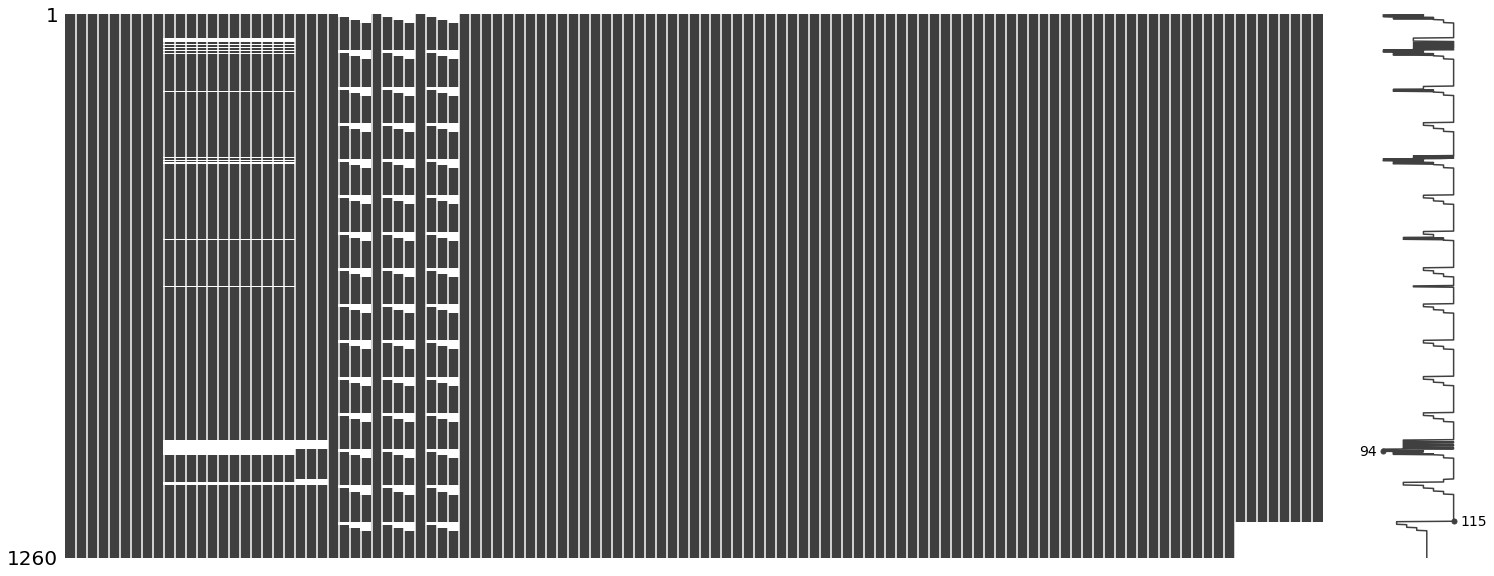

In [107]:
missingno.matrix(dataset)

In [108]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [109]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [110]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [111]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [112]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

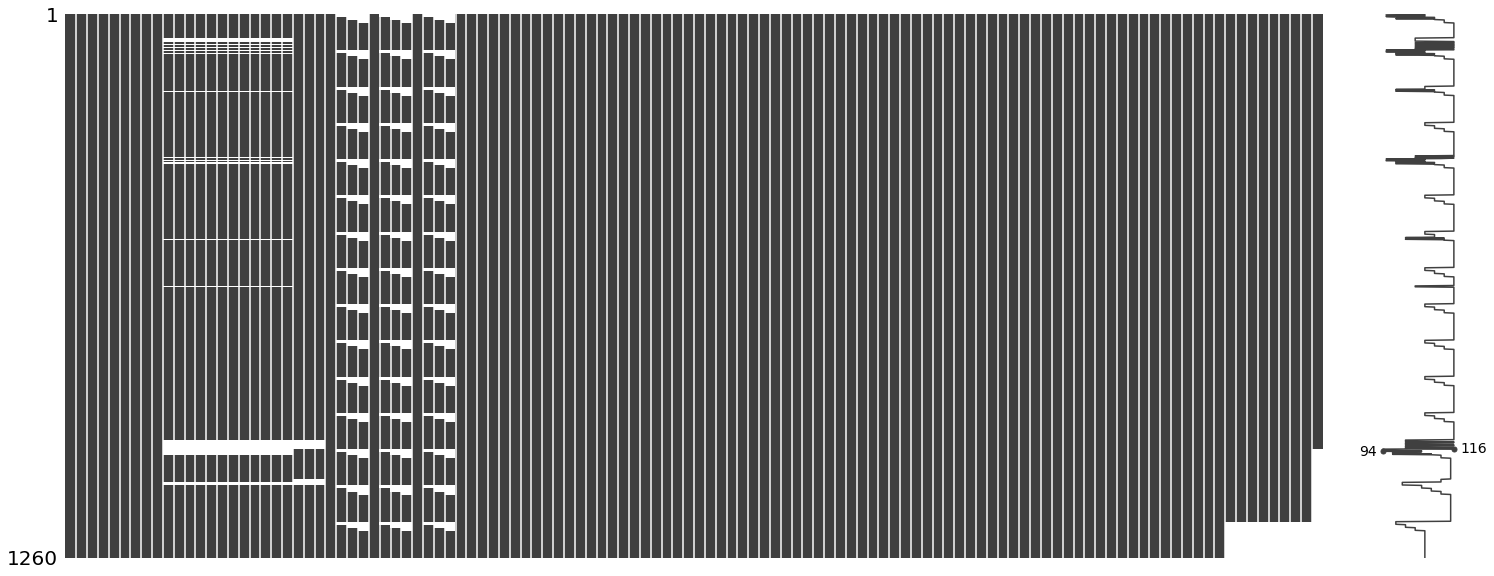

In [113]:
missingno.matrix(dataset)

In [114]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [115]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [116]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [117]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [118]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

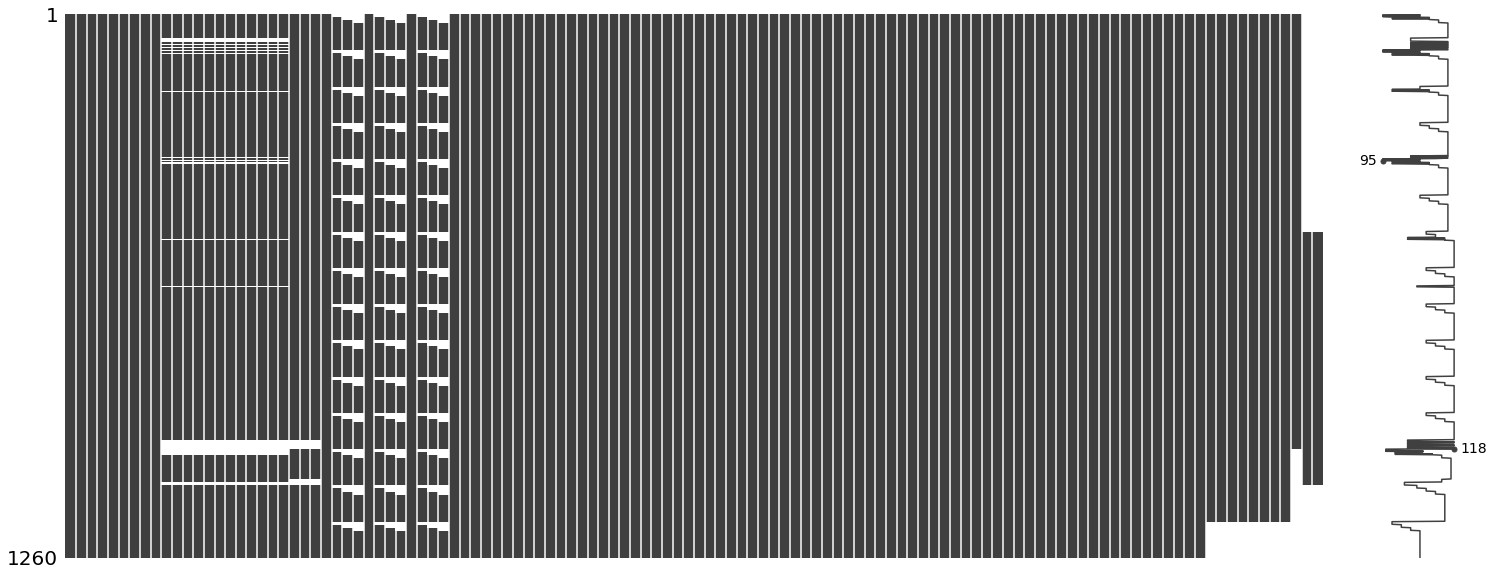

In [119]:
missingno.matrix(dataset)

In [120]:
missing = describe_dataframe(dataset)

In [121]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,6.666700
114,F_TOTAL,6.666700
115,MIO_EUR,20.000000
116,L_TOTAL,53.333300


In [122]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.000000,-11.000000,48.000000,5.500000,23.500000,24.000000,4.166667,1455.000000,296.000000,45.000000,62.908014,664.000000,194.000000,259.000000,576.000000,11723.000000,44888.000000,13557.000000,70168.000000,11361.000000,44491.000000,16024.000000,71876.000000,2098.630000,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.000000,-5.000000,47.000000,7.166667,9.500000,27.333333,5.666667,1324.000000,291.000000,35.000000,66.632744,587.000000,184.000000,280.000000,547.000000,87281.000000,374669.000000,80103.000000,542053.000000,83839.000000,403005.000000,104992.000000,591836.000000,21520.330000,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.35

In [123]:
dataset.reset_index(inplace=True, drop=True)

In [124]:
dataset['cases'].value_counts()

0     1105
1       42
2       26
3       18
4       13
5        8
6        7
11       6
7        6
10       5
12       4
8        3
13       3
9        2
20       2
17       2
41       1
50       1
16       1
34       1
27       1
40       1
49       1
36       1
Name: cases, dtype: int64

In [125]:
dataset['cases'].sum()

936

In [126]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.000000,-11.000000,48.000000,5.500000,23.500000,24.000000,4.166667,1455.000000,296.000000,45.000000,62.908014,664.000000,194.000000,259.000000,576.000000,11723.000000,44888.000000,13557.000000,70168.000000,11361.000000,44491.000000,16024.000000,71876.000000,2098.630000,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.000000,-5.000000,47.000000,7.166667,9.500000,27.333333,5.666667,1324.000000,291.000000,35.000000,66.632744,587.000000,184.000000,280.000000,547.000000,87281.000000,374669.000000,80103.000000,542053.000000,83839.000000,403005.000000,104992.000000,591836.000000,21520.330000,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.35

In [127]:
cols = dataset.columns

In [128]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [129]:
len(cols)

118

In [130]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc, index = False)
